# Genre Classification: TF-IDF Weighted Word2Vec + Support Vector Machine

Same feature representation as the Logistic Regression notebook (TF-IDF weighted Word2Vec) but with an SVM classifier. SVMs find the maximum-margin hyperplane between classes and tend to be strong on dense embedding features like Word2Vec averages.

**Two SVM variants are run for comparison:**
1. **Linear SVM** (`LinearSVC`) — fast, scales well, strong baseline for text
2. **RBF Kernel SVM** (`SVC` with `kernel='rbf'`) — captures non-linear relationships, often better on dense embeddings but much slower

**Pipeline:**
1. Load and preprocess lyrics
2. Train/test split (stratified)
3. Train Word2Vec on training lyrics only (no leakage)
4. Fit TF-IDF on training lyrics only
5. Compute TF-IDF weighted Word2Vec vectors per song
6. Train Linear SVM and RBF SVM with class balancing
7. Evaluate with accuracy, macro-F1, classification report, confusion matrix

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (only needed once)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Load Data

Adjust the path and column names to match your dataset.

In [2]:
# TODO: update this path and column names to match your dataset
DATA_PATH = '/Users/astasolbjarkadottir/Desktop/Machine Learning/Final Project/Connor/clean version/dataset.csv'
LYRICS_COL = 'lyrics_cleaned'
GENRE_COL = 'parent_genre'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[LYRICS_COL, GENRE_COL]).reset_index(drop=True)

print(f'Total songs: {len(df)}')
print('\nGenre distribution:')
print(df[GENRE_COL].value_counts())

Total songs: 15372

Genre distribution:
parent_genre
Electronic          4411
Rock                2463
Metal               2261
Folk/Country        1608
Pop                 1424
World/Regional       857
Soul/Funk            784
Asian Pop            481
Reggae/Caribbean     431
Jazz & Blues         286
Classical            222
Hip-Hop & R&B        144
Name: count, dtype: int64


## 3. Preprocessing

Lowercase, drop non-alpha tokens, drop standard English stopwords plus lyric-specific filler words, lemmatize.

In [3]:
# Standard English stopwords + lyric-specific filler words
stop_words = set(stopwords.words('english'))
lyric_filler = {
    'yeah', 'oh', 'ooh', 'uh', 'na', 'la', 'hey', 'mmm', 'whoa', 'woah',
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'pre', 'hook',
}
stop_words = stop_words.union(lyric_filler)

lemmatizer = WordNetLemmatizer()

def tokenize(text):
    """Lowercase, tokenize, drop non-alpha, drop stopwords, lemmatize."""
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    return [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]

df['tokens'] = df[LYRICS_COL].apply(tokenize)
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f'Songs after preprocessing: {len(df)}')
print(f'Avg tokens per song: {df["tokens"].apply(len).mean():.1f}')

Songs after preprocessing: 15372
Avg tokens per song: 148.4


## 4. Train/Test Split

Stratified to keep class proportions consistent across train and test.

In [4]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df[GENRE_COL],
    random_state=RANDOM_STATE,
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f'Train: {len(df_train)}  Test: {len(df_test)}')

Train: 12297  Test: 3075


## 5. Train Word2Vec

Train on the training set only. Skip-gram with `min_count=2` and 15 epochs is appropriate for a smallish lyric corpus.

In [5]:
VECTOR_SIZE = 200

w2v_model = Word2Vec(
    sentences=df_train['tokens'].tolist(),
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=2,
    workers=4,
    sg=1,              # skip-gram
    epochs=15,
    negative=10,
    seed=RANDOM_STATE,
)

print(f'Vocab size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

for word in ['love', 'fire', 'night']:
    if word in w2v_model.wv:
        print(f'\nNeighbors of "{word}":')
        for neighbor, score in w2v_model.wv.most_similar(word, topn=5):
            print(f'  {neighbor:<20} {score:.3f}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocab size: 22555
Vector size: 200

Neighbors of "love":
  know                 0.569
  looooove             0.553
  ophelia              0.550
  lovе                 0.548
  naname               0.548

Neighbors of "fire":
  yeahahahah           0.543
  bitbitbitbitbitbit   0.535
  ohohoohohoh          0.530
  stoking              0.520
  surturs              0.515

Neighbors of "night":
  slammer              0.558
  practicin            0.532
  ohohah               0.531
  reallyreally         0.528
  dumdadadum           0.505


## 6. Fit TF-IDF

Used to weight Word2Vec vectors. Fit on training data only.

In [6]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
tfidf.fit(df_train['tokens'])

vocab = tfidf.vocabulary_
idf = tfidf.idf_
word_to_idf = {word: idf[idx] for word, idx in vocab.items()}

print(f'TF-IDF vocab size: {len(vocab)}')

TF-IDF vocab size: 17840


## 7. Build TF-IDF Weighted Word2Vec Vectors

TF-IDF weights up-weight distinctive words and down-weight common ones, so the resulting vector emphasizes a song's discriminative vocabulary.

In [7]:
def tfidf_weighted_w2v(tokens, w2v_model, word_to_idf, dim):
    """Weighted average of Word2Vec vectors using TF-IDF weights."""
    if not tokens:
        return np.zeros(dim, dtype=np.float32)

    tf = {}
    for t in tokens:
        tf[t] = tf.get(t, 0) + 1
    n = len(tokens)

    weighted_sum = np.zeros(dim, dtype=np.float32)
    weight_total = 0.0

    for word, count in tf.items():
        if word in w2v_model.wv and word in word_to_idf:
            weight = (count / n) * word_to_idf[word]
            weighted_sum += weight * w2v_model.wv[word]
            weight_total += weight

    if weight_total == 0:
        return np.zeros(dim, dtype=np.float32)
    return weighted_sum / weight_total


def build_matrix(df_subset):
    return np.array([
        tfidf_weighted_w2v(tokens, w2v_model, word_to_idf, VECTOR_SIZE)
        for tokens in df_subset['tokens']
    ], dtype=np.float32)


X_train = build_matrix(df_train)
X_test = build_matrix(df_test)
y_train = df_train[GENRE_COL].values
y_test = df_test[GENRE_COL].values

print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test:  {X_test.shape}  dtype: {X_test.dtype}')

zero_train = (np.linalg.norm(X_train, axis=1) == 0).sum()
zero_test = (np.linalg.norm(X_test, axis=1) == 0).sum()
print(f'All-zero vectors — train: {zero_train}, test: {zero_test}')

X_train: (12297, 200)  dtype: float32
X_test:  (3075, 200)  dtype: float32
All-zero vectors — train: 0, test: 0


## 8a. Train Linear SVM

`LinearSVC` is the fast variant of SVM — it doesn't use the kernel trick, which makes it scale well to large datasets. For text classification it's a standard strong baseline.

**Why standardize features for SVM?** SVMs are very sensitive to feature scale because the margin calculation uses Euclidean distances. Without scaling, dimensions with larger ranges dominate the decision boundary. Always scale before SVM.

In [8]:
linear_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

linear_svm.fit(X_train, y_train)
preds_linear = linear_svm.predict(X_test)

acc_linear = accuracy_score(y_test, preds_linear)
macro_f1_linear = f1_score(y_test, preds_linear, average='macro')

print('=== Linear SVM ===')
print(f'Accuracy:    {acc_linear:.3f}')
print(f'Macro F1:    {macro_f1_linear:.3f}')
print(f'Weighted F1: {f1_score(y_test, preds_linear, average="weighted"):.3f}')
print()
print(classification_report(y_test, preds_linear))

=== Linear SVM ===
Accuracy:    0.349
Macro F1:    0.297
Weighted F1: 0.332

                  precision    recall  f1-score   support

       Asian Pop       0.41      0.45      0.43        96
       Classical       0.09      0.45      0.14        44
      Electronic       0.48      0.28      0.36       882
    Folk/Country       0.39      0.57      0.46       322
   Hip-Hop & R&B       0.08      0.59      0.14        29
    Jazz & Blues       0.07      0.26      0.11        57
           Metal       0.51      0.71      0.59       452
             Pop       0.19      0.10      0.13       285
Reggae/Caribbean       0.30      0.49      0.37        86
            Rock       0.27      0.04      0.07       493
       Soul/Funk       0.13      0.11      0.12       157
  World/Regional       0.60      0.69      0.64       172

        accuracy                           0.35      3075
       macro avg       0.29      0.39      0.30      3075
    weighted avg       0.38      0.35      0.33    

## 8b. Train RBF Kernel SVM

`SVC` with `kernel='rbf'` uses the radial basis function kernel to capture non-linear relationships. On dense embedding features (like our 200-dim Word2Vec averages), RBF often outperforms linear — but it's significantly slower (training time grows quadratically with sample size).

If your dataset is large (>20k songs) and this cell takes too long, you can either subsample for the comparison or skip RBF and stick with LinearSVC.

In [9]:
rbf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

rbf_svm.fit(X_train, y_train)
preds_rbf = rbf_svm.predict(X_test)

acc_rbf = accuracy_score(y_test, preds_rbf)
macro_f1_rbf = f1_score(y_test, preds_rbf, average='macro')

print('=== RBF Kernel SVM ===')
print(f'Accuracy:    {acc_rbf:.3f}')
print(f'Macro F1:    {macro_f1_rbf:.3f}')
print(f'Weighted F1: {f1_score(y_test, preds_rbf, average="weighted"):.3f}')
print()
print(classification_report(y_test, preds_rbf))

=== RBF Kernel SVM ===
Accuracy:    0.418
Macro F1:    0.370
Weighted F1: 0.412

                  precision    recall  f1-score   support

       Asian Pop       0.34      0.50      0.40        96
       Classical       0.12      0.32      0.18        44
      Electronic       0.59      0.34      0.43       882
    Folk/Country       0.46      0.65      0.54       322
   Hip-Hop & R&B       0.16      0.52      0.25        29
    Jazz & Blues       0.15      0.23      0.18        57
           Metal       0.56      0.73      0.64       452
             Pop       0.22      0.31      0.26       285
Reggae/Caribbean       0.42      0.52      0.46        86
            Rock       0.30      0.15      0.20       493
       Soul/Funk       0.20      0.24      0.22       157
  World/Regional       0.74      0.65      0.69       172

        accuracy                           0.42      3075
       macro avg       0.35      0.43      0.37      3075
    weighted avg       0.45      0.42      0.41

## 9. Side-by-Side Comparison

In [10]:
results = pd.DataFrame({
    'Linear SVM':  [acc_linear, macro_f1_linear],
    'RBF SVM':     [acc_rbf, macro_f1_rbf],
}, index=['Accuracy', 'Macro F1'])

print(results.round(3))

          Linear SVM  RBF SVM
Accuracy       0.349    0.418
Macro F1       0.297    0.370


## 10. Confusion Matrix (Best Model)

Visualizing which genres get confused with which. Pick whichever SVM variant did better above.

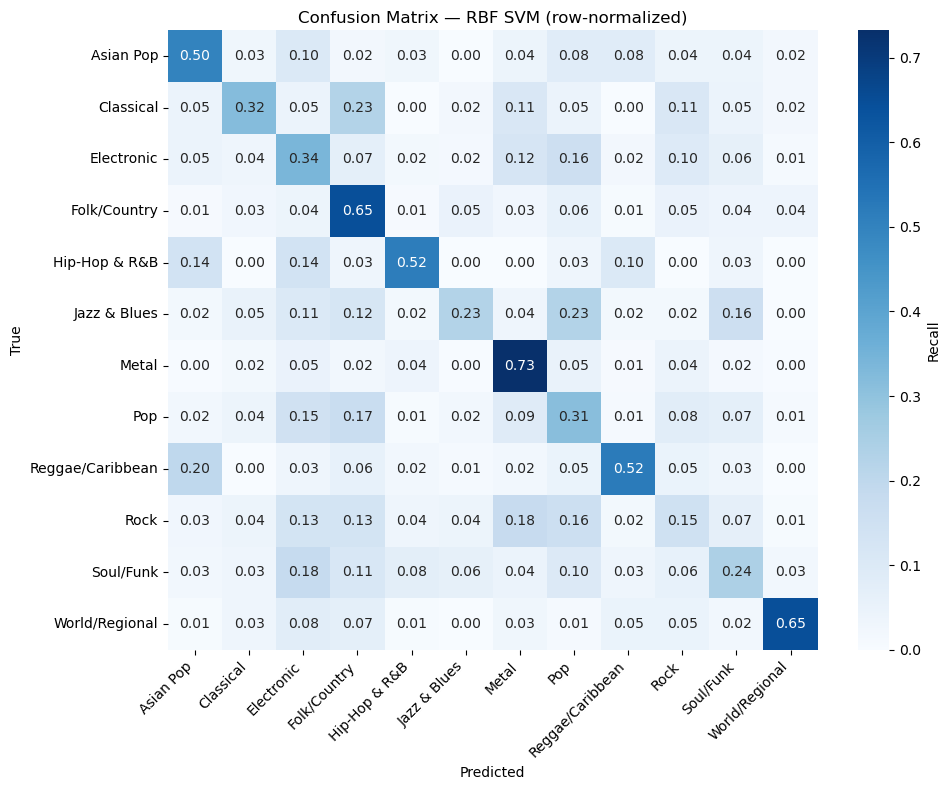

In [11]:
# Use whichever model performed better (by macro F1)
if macro_f1_rbf >= macro_f1_linear:
    best_name, best_preds = 'RBF SVM', preds_rbf
else:
    best_name, best_preds = 'Linear SVM', preds_linear

labels = sorted(df[GENRE_COL].unique())
cm = confusion_matrix(y_test, best_preds, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Recall'},
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name} (row-normalized)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Optional: Hyperparameter Tuning with GridSearchCV

If you have time, tuning `C` (and `gamma` for RBF) often gives a meaningful improvement. This is slow — comment it out if your dataset is large.

`C` controls regularization: low `C` = wide margin, more regularization, simpler boundary; high `C` = narrow margin, less regularization, fits training data more tightly.

In [12]:
from sklearn.model_selection import GridSearchCV

# Linear SVM tuning
linear_grid = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    param_grid={'svm__C': [0.01, 0.1, 1.0, 10.0]},
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
linear_grid.fit(X_train, y_train)
print(f'Best Linear SVM C: {linear_grid.best_params_}')
print(f'Best CV macro-F1: {linear_grid.best_score_:.3f}')

preds_tuned = linear_grid.predict(X_test)
print(f'\nTest accuracy:  {accuracy_score(y_test, preds_tuned):.3f}')
print(f'Test macro F1:  {f1_score(y_test, preds_tuned, average="macro"):.3f}')

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

TypeError: only integer scalar arrays can be converted to a scalar index

## Notes for Your Write-up

Things to discuss when comparing SVM to your other classifiers:

**Why SVM might do well here:** SVMs find the maximum-margin hyperplane, which often generalizes well on dense embedding features. The RBF kernel can capture non-linear genre boundaries that linear models miss.

**Why SVM might struggle:** SVMs don't natively output probabilities (without `CalibratedClassifierCV`), and they're slow on large datasets. RBF SVM in particular has $O(n^2)$ training time.

**Linear vs RBF on your data:** If RBF significantly beats Linear, your genre boundaries are non-linear in the Word2Vec space. If they're close, your features are already roughly linearly separable, which suggests TF-IDF may also do well (since linear models on sparse TF-IDF often match dense + RBF).

**Per-class differences:** Look at the classification report to see which genres each SVM variant handles best. You might find that one variant is better on rare classes and the other on common ones.

Report **Accuracy / Macro-F1** in your results table, same as the other models, for a fair comparison.